# Analiza i porównanie najlepszych konfiguracji parametrów

## Topologia meeting

In [262]:
import os
import glob

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")

# ============================================================
# LOAD RESULTS
# ============================================================

RESULTS_PATH = "./results/best_configs"

files = glob.glob(os.path.join(RESULTS_PATH, "meeting*.csv"))

print("Loaded files:")
for f in files:
    print(os.path.basename(f))

dfs = []

for file in files:
    df_tmp = pd.read_csv(file)

    # source filename
    df_tmp["source_file"] = os.path.basename(file)

    dfs.append(df_tmp)

df_meeting = pd.concat(dfs, ignore_index=True)

print(f"\nTotal rows: {len(df_meeting)}")

display(df_meeting.head())

print("\nColumns:")
print(df_meeting.columns.tolist())

Loaded files:
meeting_n200_array_20090133.csv
meeting_n50_array_20090133.csv
meeting_n300_array_20090133.csv
meeting_n500_array_20088196.csv
meeting_n500_array_20086618.csv
meeting_n100_array_20090133.csv

Total rows: 160


,array_task_id,topology,number_of_islands,number_of_migrants,migration_interval,z_star,n_steps,r0,r1,gamma,build_target_ratio,seed,average,best,source_file
0,15,meeting,200,5,5,10,500,0.001,2.0,0.001,0.8,123.0,226.052119,138.582175,meeting_n200_array_20090133.csv
1,17,meeting,200,5,5,10,500,0.001,2.0,0.001,0.8,123.0,185.759456,120.414342,meeting_n200_array_20090133.csv
2,16,meeting,200,5,5,10,500,0.001,2.0,0.001,0.8,123.0,184.270560,118.707004,meeting_n200_array_20090133.csv
3,19,meeting,200,5,5,10,500,0.001,2.0,0.001,0.8,123.0,201.008348,133.375837,meeting_n200_array_20090133.csv
4,18,meeting,200,5,5,10,500,0.001,2.0,0.001,0.8,123.0,192.866649,116.929807,meeting_n200_array_20090133.csv



Columns:
['array_task_id', 'topology', 'number_of_islands', 'number_of_migrants', 'migration_interval', 'z_star', 'n_steps', 'r0', 'r1', 'gamma', 'build_target_ratio', 'seed', 'average', 'best', 'source_file']


In [263]:
df_meeting

,array_task_id,topology,number_of_islands,number_of_migrants,migration_interval,z_star,n_steps,r0,r1,gamma,build_target_ratio,seed,average,best,source_file
0,15,meeting,200,5,5,10,500,0.001,2.0,0.001,0.8,123.0,226.052119,138.582175,meeting_n200_array_20090133.csv
1,17,meeting,200,5,5,10,500,0.001,2.0,0.001,0.8,123.0,185.759456,120.414342,meeting_n200_array_20090133.csv
2,16,meeting,200,5,5,10,500,0.001,2.0,0.001,0.8,123.0,184.270560,118.707004,meeting_n200_array_20090133.csv
3,19,meeting,200,5,5,10,500,0.001,2.0,0.001,0.8,123.0,201.008348,133.375837,meeting_n200_array_20090133.csv
4,18,meeting,200,5,5,10,500,0.001,2.0,0.001,0.8,123.0,192.866649,116.929807,meeting_n200_array_20090133.csv
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155,41,meeting,100,5,5,10,500,0.001,2.0,0.001,0.8,123.0,265.156065,181.369448,meeting_n100_array_20090133.csv
156,40,meeting,100,5,5,10,500,0.001,2.0,0.001,0.8,123.0,265.156065,181.369448,meeting_n100_array_20090133.csv
157,43,meeting,100,5,5,10,500,0.001,2.0,0.001,0.8,123.0,291.336094,208.938618,meeting_n100_array_20090133.csv
158,42,meeting,100,5,5,10,500,0.001,2.0,0.001,0.8,123.0,284.254804,208.938618,meeting_n100_array_20090133.csv


In [264]:
# W cześci wyników brakowało kolumny seed; dodajemy ją, plinując żeby nie zdublować recordów

df1 = pd.read_csv("./results/best_configs/meeting_n500_array_20086618.csv")
df2 = pd.read_csv("./results/best_configs/meeting_n500_array_20088196.csv")

df1["seed"] = 123
df2["seed"] = 124

df_meeting = pd.concat([df_meeting, df1, df2], ignore_index=True)
df_meeting.drop(columns=['source_file'], inplace=True)
df_meeting.dropna(inplace=True)

df_meeting

,array_task_id,topology,number_of_islands,number_of_migrants,migration_interval,z_star,n_steps,r0,r1,gamma,build_target_ratio,seed,average,best
0,15,meeting,200,5,5,10,500,0.00100,2.0,0.001,0.8,123.0,226.052119,138.582175
1,17,meeting,200,5,5,10,500,0.00100,2.0,0.001,0.8,123.0,185.759456,120.414342
2,16,meeting,200,5,5,10,500,0.00100,2.0,0.001,0.8,123.0,184.270560,118.707004
3,19,meeting,200,5,5,10,500,0.00100,2.0,0.001,0.8,123.0,201.008348,133.375837
4,18,meeting,200,5,5,10,500,0.00100,2.0,0.001,0.8,123.0,192.866649,116.929807
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255,45,meeting,500,5,5,10,1000,0.00025,1.0,0.001,0.8,124.0,86.208436,54.815505
256,46,meeting,500,5,5,10,1000,0.00025,1.0,0.001,0.8,124.0,82.642027,54.350293
257,47,meeting,500,5,5,10,1000,0.00025,1.0,0.001,0.8,124.0,90.017872,52.409872
258,48,meeting,500,5,5,10,1000,0.00025,1.0,0.001,0.8,124.0,103.096641,60.707945


In [265]:
# tworzymy nową kolumnę config_id do łatwego grupowania wyników

config_cols = [
    "number_of_islands",
    "number_of_islands",
    "migration_interval",
    "z_star",
    "n_steps",
    "r0",
    "r1",
    "gamma"

]

df_meeting["config_id"] = (
    df_meeting[config_cols]
    .astype(str)
    .agg("_".join, axis=1)
)

In [266]:
summary = (
    df_meeting.groupby(["number_of_islands", "config_id"])
    .agg(
        mean_best=("best", "mean"),
        std_best=("best", "std"),
        min_best=("best", "min"),
        max_best=("best", "max"),
        median_best=("best", "median"),
        mean_avg=("average", "mean"),
        std_avg=("average", "std"),
        min_avg=("average", "min"),
        max_avg=("average", "max"),
        median_avg=("average", "median"),

    )
    .reset_index()
)

In [267]:
summary

,number_of_islands,config_id,mean_best,std_best,min_best,max_best,median_best,mean_avg,std_avg,min_avg,max_avg,median_avg
0,50,50_50_5_10_500_0.0005_1.0_0.001,268.405046,8.707336,262.327615,283.791333,264.957401,301.400490,11.127146,289.359215,314.242553,306.549347
1,50,50_50_5_5_500_0.001_1.0_0.001,274.473238,10.654772,263.435803,284.660349,276.173886,308.700177,12.352903,295.711246,321.156130,310.408507
2,50,50_50_5_5_500_0.001_2.0_0.001,295.681448,6.910367,283.899089,299.909445,299.679627,327.701711,5.180299,319.597436,331.878158,329.997695
3,100,100_100_5_10_500_0.0005_1.0_0.001,192.239911,17.666228,178.405271,221.316749,188.443010,283.058601,26.737043,258.705269,323.684003,286.893793
4,100,100_100_5_10_500_0.001_1.0_0.001,197.906101,10.978013,187.742939,209.722821,193.266588,276.776850,10.869300,262.979726,286.995558,280.251539
5,100,100_100_5_10_500_0.001_2.0_0.001,201.186300,19.286161,181.369448,225.315368,208.938618,285.636312,23.536830,265.156065,322.278532,284.254804
6,200,200_200_5_10_500_0.001_2.0_0.001,125.601833,9.728530,116.929807,138.582175,120.414342,197.991427,17.034164,184.270560,226.052119,192.866649
7,200,200_200_5_5_500_0.0005_2.0_0.001,134.825414,13.607875,121.476198,151.118244,134.340540,223.611153,9.869103,213.871675,235.015188,222.407979
8,200,200_200_5_5_500_0.001_2.0_0.001,127.625744,5.298266,125.256287,137.103570,125.256287,212.717722,10.868864,207.432653,232.140465,207.918391
9,300,300_300_5_10_1000_0.00025_2.0_0.005,76.063546,2.816583,71.169615,78.027410,77.260772,131.699944,4.323900,128.400169,138.975611,129.691545


In [268]:
summary.sort_values("mean_best")

,number_of_islands,config_id,mean_best,std_best,min_best,max_best,median_best,mean_avg,std_avg,min_avg,max_avg,median_avg
17,500,500_500_5_10_1000_0.001_1.0_0.005,48.032353,6.701763,41.876836,65.301730,46.748644,77.012489,10.831273,68.496999,102.397208,74.250779
14,500,500_500_5_10_1000_0.0005_1.0_0.005,50.724921,7.185516,43.346698,62.711942,51.016163,77.977348,10.978336,72.829255,109.130442,74.616853
18,500,500_500_5_10_1000_0.001_3.0_0.0005,50.934436,5.735886,45.995673,63.802727,50.395138,81.773952,7.426703,76.856143,97.856586,78.454168
16,500,500_500_5_10_1000_0.0005_3.0_0.0005,53.298815,4.900587,46.193249,61.995054,53.801934,87.245777,7.218597,78.016686,102.700413,87.594781
15,500,500_500_5_10_1000_0.0005_2.0_0.0005,54.125313,4.454661,44.642120,59.999178,54.708980,90.405023,7.075814,74.386202,100.248413,91.547679
19,500,500_500_5_10_1000_0.001_3.0_0.005,54.153718,3.702524,49.319603,60.331794,54.008542,86.636708,8.457295,78.839360,100.703857,84.929635
21,500,500_500_5_10_500_0.001_1.0_0.001,54.628574,3.836113,50.164994,59.175331,55.092338,83.619754,4.037777,80.696889,92.178045,82.316359
13,500,500_500_5_10_1000_0.00025_2.0_0.005,54.759975,8.711881,39.951813,65.316857,54.652102,90.273223,8.611177,75.740536,102.444756,91.174411
12,500,500_500_5_10_1000_0.00025_1.0_0.001,54.951455,6.385263,47.809397,66.077092,54.582899,92.257564,10.317508,79.848884,109.891911,88.113154
20,500,500_500_5_10_500_0.0005_1.0_0.001,55.856304,7.083730,46.530848,72.061623,54.786259,92.932170,8.205335,79.006142,106.979668,90.397142


In [269]:
summary.sort_values("median_best")

,number_of_islands,config_id,mean_best,std_best,min_best,max_best,median_best,mean_avg,std_avg,min_avg,max_avg,median_avg
17,500,500_500_5_10_1000_0.001_1.0_0.005,48.032353,6.701763,41.876836,65.301730,46.748644,77.012489,10.831273,68.496999,102.397208,74.250779
18,500,500_500_5_10_1000_0.001_3.0_0.0005,50.934436,5.735886,45.995673,63.802727,50.395138,81.773952,7.426703,76.856143,97.856586,78.454168
14,500,500_500_5_10_1000_0.0005_1.0_0.005,50.724921,7.185516,43.346698,62.711942,51.016163,77.977348,10.978336,72.829255,109.130442,74.616853
16,500,500_500_5_10_1000_0.0005_3.0_0.0005,53.298815,4.900587,46.193249,61.995054,53.801934,87.245777,7.218597,78.016686,102.700413,87.594781
19,500,500_500_5_10_1000_0.001_3.0_0.005,54.153718,3.702524,49.319603,60.331794,54.008542,86.636708,8.457295,78.839360,100.703857,84.929635
12,500,500_500_5_10_1000_0.00025_1.0_0.001,54.951455,6.385263,47.809397,66.077092,54.582899,92.257564,10.317508,79.848884,109.891911,88.113154
13,500,500_500_5_10_1000_0.00025_2.0_0.005,54.759975,8.711881,39.951813,65.316857,54.652102,90.273223,8.611177,75.740536,102.444756,91.174411
15,500,500_500_5_10_1000_0.0005_2.0_0.0005,54.125313,4.454661,44.642120,59.999178,54.708980,90.405023,7.075814,74.386202,100.248413,91.547679
20,500,500_500_5_10_500_0.0005_1.0_0.001,55.856304,7.083730,46.530848,72.061623,54.786259,92.932170,8.205335,79.006142,106.979668,90.397142
21,500,500_500_5_10_500_0.001_1.0_0.001,54.628574,3.836113,50.164994,59.175331,55.092338,83.619754,4.037777,80.696889,92.178045,82.316359


<Axes: xlabel='number_of_islands', ylabel='best'>

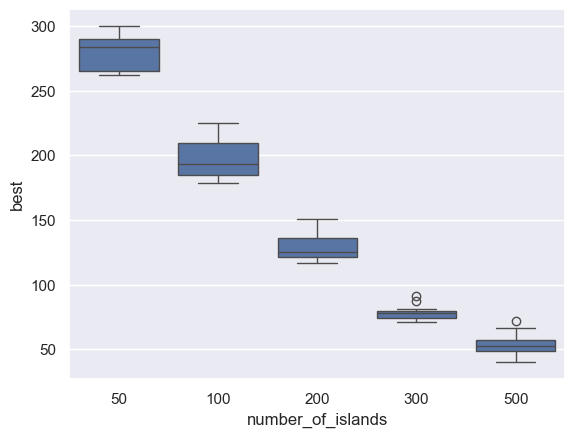

In [270]:
sns.boxplot(
    data=df_meeting,
    x="number_of_islands",
    y="best"
)

### Porównanie wyników dla dwóch różnych seedów

In [271]:
df_meeting.groupby(["config_id", "seed"])["best"].agg(["mean", "std", "min", "max", "median"])

,,mean,std,min,max,median
config_id,seed,,,,,
100_100_5_10_500_0.0005_1.0_0.001,123.0,192.239911,17.666228,178.405271,221.316749,188.443010
100_100_5_10_500_0.001_1.0_0.001,123.0,197.906101,10.978013,187.742939,209.722821,193.266588
100_100_5_10_500_0.001_2.0_0.001,123.0,201.186300,19.286161,181.369448,225.315368,208.938618
200_200_5_10_500_0.001_2.0_0.001,123.0,125.601833,9.728530,116.929807,138.582175,120.414342
200_200_5_5_500_0.0005_2.0_0.001,123.0,134.825414,13.607875,121.476198,151.118244,134.340540
200_200_5_5_500_0.001_2.0_0.001,123.0,127.625744,5.298266,125.256287,137.103570,125.256287
300_300_5_10_1000_0.00025_2.0_0.005,123.0,76.063546,2.816583,71.169615,78.027410,77.260772
300_300_5_10_1000_0.001_2.0_0.005,123.0,75.834477,4.511627,72.539650,80.776717,72.539650
300_300_5_10_500_0.001_1.0_0.001,123.0,82.346239,6.430024,77.723399,90.877515,77.723399


In [272]:
df_meeting.groupby(["seed"])["best"].agg(["mean", "std", "min", "max", "median"])

,mean,std,min,max,median
seed,,,,,
123.0,117.851339,81.584885,44.642120,299.909445,76.743496
124.0,52.239157,6.488509,39.951813,64.272923,53.864066


## Scale-free topology

In [273]:
RESULTS_PATH = "./results/best_configs"

files = glob.glob(os.path.join(RESULTS_PATH, "scale_free*.csv"))

print("Loaded files:")
for f in files:
    print(os.path.basename(f))

dfs = []

for file in files:
    df_tmp = pd.read_csv(file)

    # source filename
    df_tmp["source_file"] = os.path.basename(file)

    dfs.append(df_tmp)

df_scale_free = pd.concat(dfs, ignore_index=True)

print(f"\nTotal rows: {len(df_scale_free)}")

display(df_scale_free.head())

Loaded files:
scale_free_n50_array_20090203.csv
scale_free_n300_array_20090203.csv
scale_free_n200_array_20090203.csv
scale_free_n100_array_20090203.csv
scale_free_n500_array_20090203.csv

Total rows: 110


,array_task_id,topology,number_of_islands,number_of_migrants,migration_interval,m0,m,seed,average,best,source_file
0,45,scale_free,50,5,5,8,8,123,297.895726,257.308822,scale_free_n50_array_20090203.csv
1,47,scale_free,50,5,5,8,8,123,295.950150,253.431346,scale_free_n50_array_20090203.csv
2,46,scale_free,50,5,5,8,8,123,291.542463,250.123698,scale_free_n50_array_20090203.csv
3,49,scale_free,50,5,5,8,8,123,293.432904,258.950767,scale_free_n50_array_20090203.csv
4,48,scale_free,50,5,5,8,8,123,292.562652,258.950767,scale_free_n50_array_20090203.csv


In [274]:
config_cols = [
    "number_of_islands",
    "number_of_islands",
    "migration_interval",
    "m0",
    "m"
]

df_scale_free["config_id"] = (
    df_scale_free[config_cols]
    .astype(str)
    .agg("_".join, axis=1)
)

In [275]:
summary = (
    df_scale_free.groupby(["number_of_islands", "config_id"])
    .agg(
        mean_best=("best", "mean"),
        std_best=("best", "std"),
        min_best=("best", "min"),
        max_best=("best", "max"),
        median_best=("best", "median"),
        mean_avg=("average", "mean"),
        std_avg=("average", "std"),
        min_avg=("average", "min"),
        max_avg=("average", "max"),
        median_avg=("average", "median"),

    )
    .reset_index()
)

summary.sort_values("mean_best")

,number_of_islands,config_id,mean_best,std_best,min_best,max_best,median_best,mean_avg,std_avg,min_avg,max_avg,median_avg
18,500,500_500_5_8_7,37.594513,4.993005,33.451550,46.282137,35.898517,122.382552,5.424762,114.470519,126.347603,126.085589
19,500,500_500_5_8_8,38.190135,3.485311,33.999363,43.319220,38.736242,124.710155,10.159658,114.334482,136.710644,119.002254
17,500,500_500_5_8_6,45.278975,2.749956,43.319220,49.068386,43.319220,129.632757,29.125558,114.342446,181.205020,114.362919
16,500,500_500_5_8_5,47.586187,1.791137,46.282137,50.640979,47.356855,118.211823,5.202309,114.389131,123.928367,114.441907
14,500,500_500_5_5_5,54.600703,2.944997,52.385599,59.536032,53.271632,151.655266,11.669728,144.369840,183.502872,150.636390
13,500,500_500_5_5_4,61.889054,4.767145,55.081485,68.244026,62.446834,220.427483,46.492968,182.839983,314.994227,191.345774
15,500,500_500_5_8_4,65.781939,6.864092,57.711862,71.160442,70.000419,186.896936,32.014843,151.810437,210.280628,210.273815
10,300,300_300_5_8_7,68.188925,5.601091,62.680652,76.231299,69.517067,136.234525,2.712324,134.546716,141.008910,135.482617
11,300,300_300_5_8_8,73.511324,6.167639,68.674074,83.152390,69.981790,148.355536,16.663095,134.546716,172.306514,139.081615
9,300,300_300_5_8_5,79.568247,5.542591,70.964151,83.612400,83.152390,161.001363,5.877712,156.304302,171.217020,158.933759


<Axes: xlabel='number_of_islands', ylabel='best'>

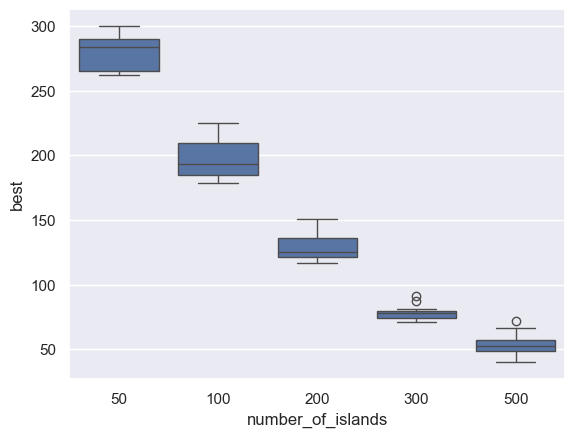

In [276]:
sns.boxplot(
    data=df_meeting,
    x="number_of_islands",
    y="best"
)

## Complete topology

In [277]:
RESULTS_PATH = "./results/best_configs"

files = glob.glob(os.path.join(RESULTS_PATH, "complete*.csv"))

print("Loaded files:")
for f in files:
    print(os.path.basename(f))

dfs = []

for file in files:
    df_tmp = pd.read_csv(file)

    # source filename
    df_tmp["source_file"] = os.path.basename(file)

    dfs.append(df_tmp)

df_complete = pd.concat(dfs, ignore_index=True)

print(f"\nTotal rows: {len(df_complete)}")

display(df_complete.head())

Loaded files:
complete_n100_array_20089275.csv
complete_n500_array_20089275.csv
complete_n50_array_20089275.csv
complete_n300_array_20089275.csv
complete_n200_array_20089275.csv

Total rows: 50


,array_task_id,topology,number_of_islands,number_of_migrants,migration_interval,average,best,source_file
0,10,complete,100,5,5,256.636619,194.201956,complete_n100_array_20089275.csv
1,11,complete,100,5,5,244.911136,188.233921,complete_n100_array_20089275.csv
2,12,complete,100,5,5,238.446188,183.901041,complete_n100_array_20089275.csv
3,15,complete,100,5,5,238.082487,183.901041,complete_n100_array_20089275.csv
4,13,complete,100,5,5,238.082487,183.901041,complete_n100_array_20089275.csv


In [278]:
complete_summary = (
    df_complete.groupby(["number_of_islands"])
    .agg(
        mean_best=("best", "mean"),
        std_best=("best", "std"),
        min_best=("best", "min"),
        max_best=("best", "max"),
        median_best=("best", "median"),
        mean_avg=("average", "mean"),
        std_avg=("average", "std"),
        min_avg=("average", "min"),
        max_avg=("average", "max"),
        median_avg=("average", "median"),
    )
    .reset_index()
)

In [279]:
complete_summary

,number_of_islands,mean_best,std_best,min_best,max_best,median_best,mean_avg,std_avg,min_avg,max_avg,median_avg
0,50,240.530346,10.641311,219.601881,249.971591,244.700878,272.610374,3.354719,269.184496,279.067154,271.588151
1,100,185.466880,7.802662,178.323377,202.991137,183.901041,253.267865,16.844061,237.799160,279.197733,248.635162
2,200,112.176138,5.104250,104.953005,120.393763,111.439655,193.843382,13.374881,186.661427,224.137980,187.953827
3,300,70.783465,7.850891,62.350273,85.147444,68.703322,139.285966,9.789697,126.280659,153.842685,139.679105
4,500,41.852309,4.332086,36.862251,50.150453,39.753898,75.494119,8.125455,66.297343,90.336835,74.889855


# Porównanie 3 najlepszych konfiguracji meeting i scale-free z complete

In [280]:
meeting_top3 = (
    df_meeting
    .groupby("config_id", as_index=False)
    .agg(mean_best=("best", "mean"))
    .sort_values("mean_best")
    .head(3)
)

In [281]:
meeting_top3_df = df_meeting[
    df_meeting["config_id"].isin(meeting_top3["config_id"])
]

In [282]:
meeting_summary = (
    meeting_top3_df
    .groupby("config_id", as_index=False)
    .agg(
        mean_best=("best", "mean"),
        std_best=("best", "std"),
        min_best=("best", "min"),
        max_best=("best", "max"),
        median_best=("best", "median"),
        mean_avg=("average", "mean"),
        std_avg=("average", "std"),
        min_avg=("average", "min"),
        max_avg=("average", "max"),
        median_avg=("average", "median"),
    )
)

meeting_summary["topology"] = "meeting"
meeting_summary

,config_id,mean_best,std_best,min_best,max_best,median_best,mean_avg,std_avg,min_avg,max_avg,median_avg,topology
0,500_500_5_10_1000_0.0005_1.0_0.005,50.724921,7.185516,43.346698,62.711942,51.016163,77.977348,10.978336,72.829255,109.130442,74.616853,meeting
1,500_500_5_10_1000_0.001_1.0_0.005,48.032353,6.701763,41.876836,65.301730,46.748644,77.012489,10.831273,68.496999,102.397208,74.250779,meeting
2,500_500_5_10_1000_0.001_3.0_0.0005,50.934436,5.735886,45.995673,63.802727,50.395138,81.773952,7.426703,76.856143,97.856586,78.454168,meeting


In [283]:
scale_free_top3 = (
    df_scale_free
    .groupby("config_id", as_index=False)
    .agg(mean_best=("best", "mean"))
    .sort_values("mean_best")
    .head(3)
)

scale_free_top3_df = df_scale_free[
    df_scale_free["config_id"].isin(scale_free_top3["config_id"])
]

scale_free_summary = (
    scale_free_top3_df
    .groupby("config_id", as_index=False)
    .agg(
        mean_best=("best", "mean"),
        std_best=("best", "std"),
        min_best=("best", "min"),
        max_best=("best", "max"),
        median_best=("best", "median"),
        mean_avg=("average", "mean"),
        std_avg=("average", "std"),
        min_avg=("average", "min"),
        max_avg=("average", "max"),
        median_avg=("average", "median"),
    )
)

scale_free_summary["topology"] = "scale_free"
scale_free_summary

,config_id,mean_best,std_best,min_best,max_best,median_best,mean_avg,std_avg,min_avg,max_avg,median_avg,topology
0,500_500_5_8_6,45.278975,2.749956,43.319220,49.068386,43.319220,129.632757,29.125558,114.342446,181.205020,114.362919,scale_free
1,500_500_5_8_7,37.594513,4.993005,33.451550,46.282137,35.898517,122.382552,5.424762,114.470519,126.347603,126.085589,scale_free
2,500_500_5_8_8,38.190135,3.485311,33.999363,43.319220,38.736242,124.710155,10.159658,114.334482,136.710644,119.002254,scale_free


In [284]:
# COMPLETE
complete_summary = (
    df_complete_500
    .groupby("topology", as_index=False)
    .agg(
        mean_best=("best", "mean"),
        std_best=("best", "std"),
        min_best=("best", "min"),
        max_best=("best", "max"),
        median_best=("best", "median"),
        mean_avg=("average", "mean"),
        std_avg=("average", "std"),
        min_avg=("average", "min"),
        max_avg=("average", "max"),
        median_avg=("average", "median"),
    )
)

In [285]:
comparison = pd.concat(
    [complete_summary, meeting_summary, scale_free_summary],
    ignore_index=True
)

In [286]:
comparison

,topology,mean_best,std_best,min_best,max_best,median_best,mean_avg,std_avg,min_avg,max_avg,median_avg,config_id
0,complete,41.852309,4.332086,36.862251,50.150453,39.753898,75.494119,8.125455,66.297343,90.336835,74.889855,NaN
1,meeting,50.724921,7.185516,43.346698,62.711942,51.016163,77.977348,10.978336,72.829255,109.130442,74.616853,500_500_5_10_1000_0.0005_1.0_0.005
2,meeting,48.032353,6.701763,41.876836,65.301730,46.748644,77.012489,10.831273,68.496999,102.397208,74.250779,500_500_5_10_1000_0.001_1.0_0.005
3,meeting,50.934436,5.735886,45.995673,63.802727,50.395138,81.773952,7.426703,76.856143,97.856586,78.454168,500_500_5_10_1000_0.001_3.0_0.0005
4,scale_free,45.278975,2.749956,43.319220,49.068386,43.319220,129.632757,29.125558,114.342446,181.205020,114.362919,500_500_5_8_6
5,scale_free,37.594513,4.993005,33.451550,46.282137,35.898517,122.382552,5.424762,114.470519,126.347603,126.085589,500_500_5_8_7
6,scale_free,38.190135,3.485311,33.999363,43.319220,38.736242,124.710155,10.159658,114.334482,136.710644,119.002254,500_500_5_8_8


<Axes: xlabel='topology', ylabel='mean_best'>

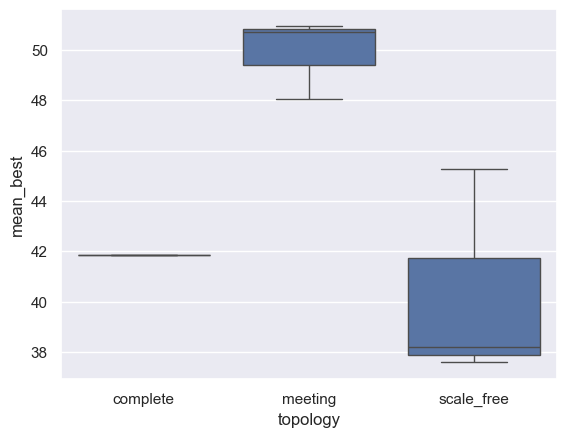

In [287]:
sns.boxplot(
    data=comparison,
    x="topology",
    y="mean_best"
)

# Porównanie 3 najlepszych konfiguracji dla różnej liczby wysp

In [288]:
# ograniczamy wyniki dla 500 wysp do top3 konfiguracji w celu rzetelego porównania
df_meeting_filtered = pd.concat([
    # wszystko poza 500
    df_meeting[df_meeting["number_of_islands"] != 500],

    # tylko top3 dla 500
    meeting_top3_df
])

In [289]:
df_scale_free_filtered = pd.concat([
    df_scale_free[df_scale_free["number_of_islands"] != 500],
    scale_free_top3_df
])

In [290]:
df_compare = pd.concat([df_complete, df_meeting_filtered, df_scale_free_filtered])
df_compare

,array_task_id,topology,number_of_islands,number_of_migrants,migration_interval,average,best,source_file,z_star,n_steps,r0,r1,gamma,build_target_ratio,seed,config_id,m0,m
0,10,complete,100,5,5,256.636619,194.201956,complete_n100_array_20089275.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,11,complete,100,5,5,244.911136,188.233921,complete_n100_array_20089275.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,12,complete,100,5,5,238.446188,183.901041,complete_n100_array_20089275.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,15,complete,100,5,5,238.082487,183.901041,complete_n100_array_20089275.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,13,complete,100,5,5,238.082487,183.901041,complete_n100_array_20089275.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,72,scale_free,500,5,5,114.342446,43.319220,scale_free_n500_array_20090203.csv,NaN,NaN,NaN,NaN,NaN,NaN,123.0,500_500_5_8_6,8.0,6.0
76,77,scale_free,500,5,5,119.002254,38.736242,scale_free_n500_array_20090203.csv,NaN,NaN,NaN,NaN,NaN,NaN,123.0,500_500_5_8_8,8.0,8.0
77,76,scale_free,500,5,5,118.996302,38.736242,scale_free_n500_array_20090203.csv,NaN,NaN,NaN,NaN,NaN,NaN,123.0,500_500_5_8_8,8.0,8.0
78,78,scale_free,500,5,5,136.710644,36.159610,scale_free_n500_array_20090203.csv,NaN,NaN,NaN,NaN,NaN,NaN,123.0,500_500_5_8_8,8.0,8.0


In [291]:
df_islands_compare = (
    df_compare.groupby(
        ["topology", "number_of_islands"],
        as_index=False
    )
    .agg(
        mean_best=("best", "mean"),
        std_best=("best", "std"),
        min_best=("best", "min"),
        max_best=("best", "max"),
        median_best=("best", "median"),
        mean_avg=("average", "mean"),
        std_avg=("average", "std"),
        min_avg=("average", "min"),
        max_avg=("average", "max"),
        median_avg=("average", "median"),
    )
)

display(df_islands_compare)

,topology,number_of_islands,mean_best,std_best,min_best,max_best,median_best,mean_avg,std_avg,min_avg,max_avg,median_avg
0,complete,50,240.530346,10.641311,219.601881,249.971591,244.700878,272.610374,3.354719,269.184496,279.067154,271.588151
1,complete,100,185.466880,7.802662,178.323377,202.991137,183.901041,253.267865,16.844061,237.799160,279.197733,248.635162
2,complete,200,112.176138,5.104250,104.953005,120.393763,111.439655,193.843382,13.374881,186.661427,224.137980,187.953827
3,complete,300,70.783465,7.850891,62.350273,85.147444,68.703322,139.285966,9.789697,126.280659,153.842685,139.679105
4,complete,500,41.852309,4.332086,36.862251,50.150453,39.753898,75.494119,8.125455,66.297343,90.336835,74.889855
5,meeting,50,279.519911,14.637043,262.327615,299.909445,283.791333,312.600792,14.775629,289.359215,331.878158,314.242553
6,meeting,100,197.110771,15.636752,178.405271,225.315368,193.266588,281.823921,20.276010,258.705269,323.684003,284.254804
7,meeting,200,129.350997,10.234991,116.929807,151.118244,125.256287,211.440101,16.203934,184.270560,235.015188,208.647736
8,meeting,300,78.081421,5.445042,71.169615,90.877515,77.723399,130.274105,6.895199,118.397145,140.101723,130.772307
9,meeting,500,49.897237,6.479137,41.876836,65.301730,47.771670,78.921263,9.762152,68.496999,109.130442,76.281302


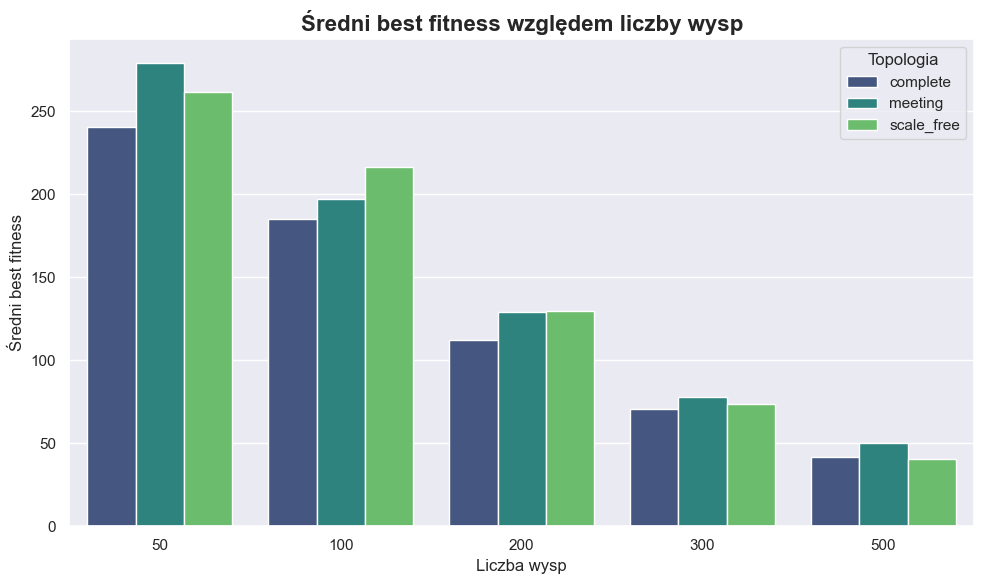

In [292]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_islands_compare,
    x="number_of_islands",
    y="mean_best",
    hue="topology",
    palette="viridis",
)

plt.title(
    "Średni best fitness względem liczby wysp",
    fontsize=16,
    fontweight="bold",
)

plt.xlabel("Liczba wysp")
plt.ylabel("Średni best fitness")

plt.legend(title="Topologia")

plt.tight_layout()
plt.show()

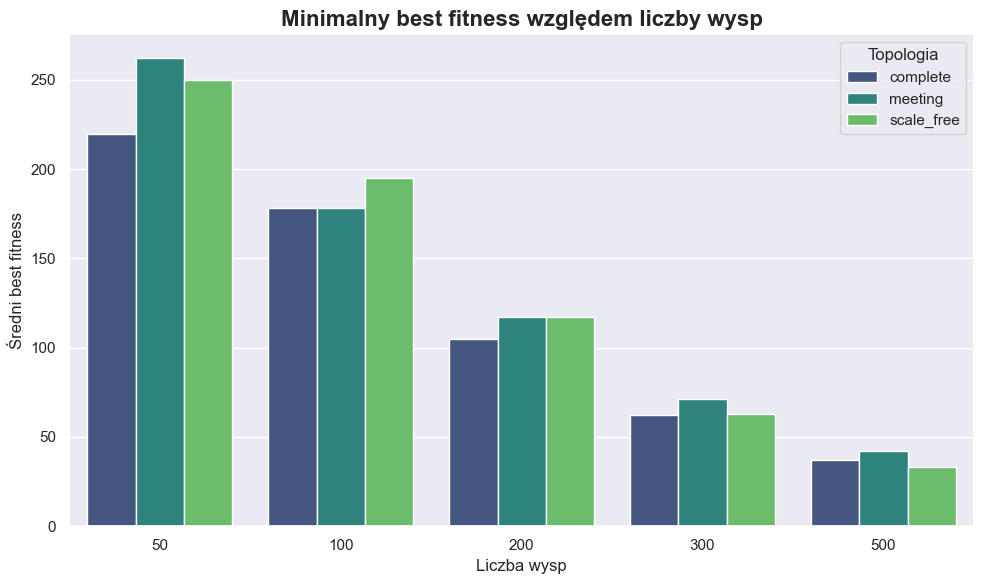

In [293]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_islands_compare,
    x="number_of_islands",
    y="min_best",
    hue="topology",
    palette="viridis",
)

plt.title(
    "Minimalny best fitness względem liczby wysp",
    fontsize=16,
    fontweight="bold",
)

plt.xlabel("Liczba wysp")
plt.ylabel("Średni best fitness")

plt.legend(title="Topologia")

plt.tight_layout()
plt.show()

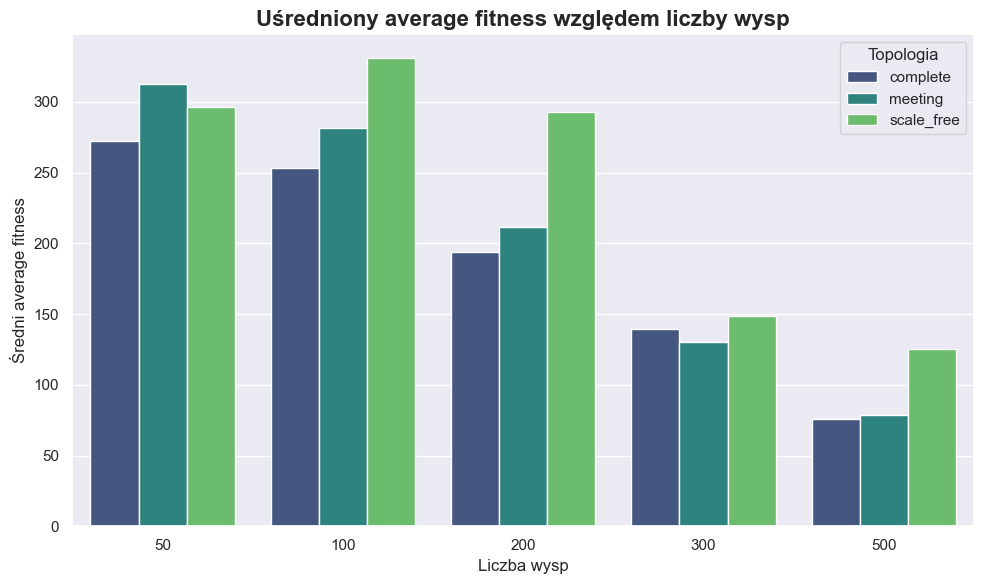

In [294]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_islands_compare,
    x="number_of_islands",
    y="mean_avg",
    hue="topology",
    palette="viridis",
)

plt.title(
    "Uśredniony average fitness względem liczby wysp",
    fontsize=16,
    fontweight="bold",
)

plt.xlabel("Liczba wysp")
plt.ylabel("Średni average fitness")

plt.legend(title="Topologia")

plt.tight_layout()
plt.show()